# 🌫️ Air Quality EDA — station_day.csv

**Dataset:** Daily pollutant readings across 110 Indian monitoring stations (2015–2020)  

**Records:** 108,035 rows × 16 columns  

**EDA Flow:** Following the 8-step EDA Guide

**Dataset Source:** Taken from kaggle.

---

## Step 1 — Understand the Data

| Column | Type | Description |
|--------|------|-------------|
| `StationId` | Categorical | Unique station identifier (e.g., AP001) |
| `Date` | Date string | Observation date (YYYY-MM-DD) |
| `PM2.5` | Float | Fine particulate matter (µg/m³) |
| `PM10` | Float | Coarse particulate matter (µg/m³) |
| `NO`, `NO2`, `NOx` | Float | Nitrogen oxides (µg/m³) |
| `NH3` | Float | Ammonia (µg/m³) |
| `CO` | Float | Carbon monoxide (mg/m³) |
| `SO2` | Float | Sulphur dioxide (µg/m³) |
| `O3` | Float | Ozone (µg/m³) |
| `Benzene`, `Toluene`, `Xylene` | Float | VOC compounds (µg/m³) |
| `AQI` | Float | Air Quality Index (computed) |
| `AQI_Bucket` | Categorical | AQI category: Good → Severe |

**Research Questions:**
- Which pollutants are most significant drivers of AQI?
- Are there seasonal patterns in air quality?
- Which stations consistently show poor air quality?
- What are the relationships between co-pollutants?

## Step 2 — Import & Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

# ── Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv('station_day.csv', parse_dates=['Date'])

print(f"Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Stations   : {df['StationId'].nunique()} unique")
df.head()

Shape      : 108,035 rows × 16 columns
Date range : 2015-01-01  →  2020-07-01
Stations   : 110 unique


,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate


In [3]:
# Data types & basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108035 entries, 0 to 108034
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   StationId   108035 non-null  object        
 1   Date        108035 non-null  datetime64[ns]
 2   PM2.5       86410 non-null   float64       
 3   PM10        65329 non-null   float64       
 4   NO          90929 non-null   float64       
 5   NO2         91488 non-null   float64       
 6   NOx         92535 non-null   float64       
 7   NH3         59930 non-null   float64       
 8   CO          95037 non-null   float64       
 9   SO2         82831 non-null   float64       
 10  O3          82467 non-null   float64       
 11  Benzene     76580 non-null   float64       
 12  Toluene     69333 non-null   float64       
 13  Xylene      22898 non-null   float64       
 14  AQI         87025 non-null   float64       
 15  AQI_Bucket  87025 non-null   object        
dtypes:

In [4]:
# Summary statistics for all numeric columns
df.select_dtypes(include=np.number).describe().T.style.background_gradient(cmap='YlOrRd', subset=['mean','min', 'max'])

,count,mean,std,min,25%,50%,75%,max
PM2.5,86410.000000,80.272571,76.526403,0.020000,31.880000,55.950000,99.920000,1000.000000
PM10,65329.000000,157.968427,123.418672,0.010000,70.150000,122.090000,208.670000,1000.000000
NO,90929.000000,23.123424,34.491019,0.010000,4.840000,10.290000,24.980000,470.000000
NO2,91488.000000,35.240760,29.510827,0.010000,15.090000,27.210000,46.930000,448.050000
NOx,92535.000000,41.195055,45.145976,0.000000,13.970000,26.660000,50.500000,467.630000
NH3,59930.000000,28.732875,24.897797,0.010000,11.900000,23.590000,38.137500,418.900000
CO,95037.000000,1.605749,4.369578,0.000000,0.530000,0.910000,1.450000,175.810000
SO2,82831.000000,12.257634,12.984723,0.010000,5.040000,8.950000,14.920000,195.650000
O3,82467.000000,38.134836,39.128004,0.010000,18.895000,30.840000,47.140000,963.000000
Benzene,76580.000000,3.358029,11.156234,0.000000,0.160000,1.210000,3.610000,455.030000


## Step 3 — Handle Missing Data

            Missing Count  Missing %
Xylene              85137       78.8
NH3                 48105       44.5
PM10                42706       39.5
Toluene             38702       35.8
Benzene             31455       29.1
O3                  25568       23.7
SO2                 25204       23.3
PM2.5               21625       20.0
AQI                 21010       19.4
AQI_Bucket          21010       19.4
NO                  17106       15.8
NO2                 16547       15.3
NOx                 15500       14.3
CO                  12998       12.0
['#d62728', '#ff7f0e', '#ff7f0e', '#ff7f0e', '#ff7f0e', '#ff7f0e', '#ff7f0e', '#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c']


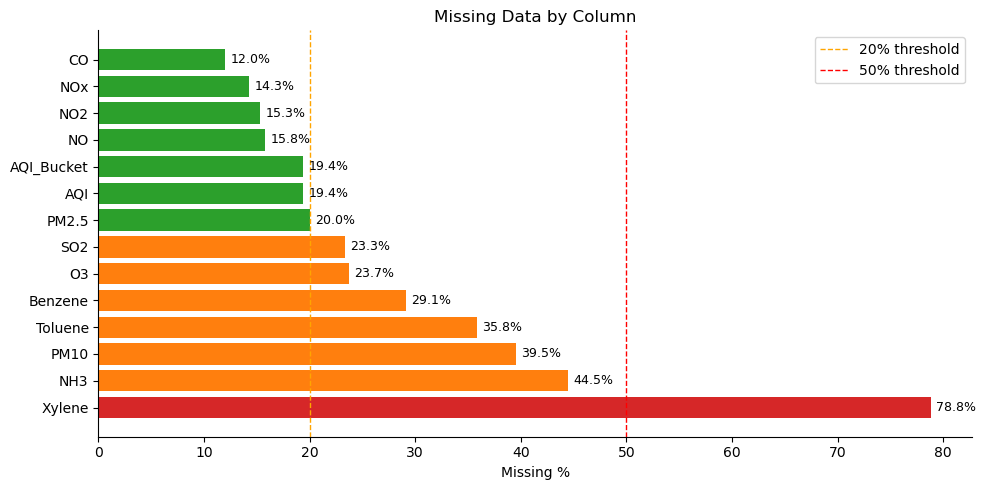

In [5]:
# ── Missing value audit ────────────────────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]

print(miss_df.to_string())

# Visual
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if p > 50 else '#ff7f0e' if p > 20 else '#2ca02c'
          for p in missing_pct[missing_pct > 0]]
print(colors)
bars = ax.barh(miss_df.index, miss_df['Missing %'], color=colors)
ax.axvline(20, color='orange', linestyle='--', linewidth=1, label='20% threshold')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Missing Data by Column')
ax.legend()
for bar, pct in zip(bars, miss_df['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,f'{pct}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
miss_df.index

Index(['Xylene', 'NH3', 'PM10', 'Toluene', 'Benzene', 'O3', 'SO2', 'PM2.5',
       'AQI', 'AQI_Bucket', 'NO', 'NO2', 'NOx', 'CO'],
      dtype='object')

In [7]:
# ── Strategy ──────────────────────────────────────────────────────────────
# Xylene: 78.8% missing → drop column (too sparse to impute reliably)

# Others: <40%  missing → median impute per station (preserves local patterns)

df.drop(columns=['Xylene'], inplace=True)
print("Dropped 'Xylene' (78.8% missing)")

Dropped 'Xylene' (78.8% missing)


In [8]:
df.shape

(108035, 15)

In [9]:

pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
              'O3', 'Benzene', 'Toluene']
len(pollutants)

11

In [10]:
df.groupby('StationId')[pollutants].median()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene
StationId,,,,,,,,,,,
AP001,28.015,64.895,3.240,15.350,10.990,11.265,0.59,13.030,32.965,0.120,0.945
AP005,40.610,100.685,10.510,35.500,24.550,10.770,0.76,10.330,28.800,4.040,8.000
AS001,46.780,87.975,10.250,12.050,27.230,8.940,0.59,13.920,19.180,0.430,NaN
BR005,43.630,71.930,51.680,22.605,12.505,17.440,0.50,5.590,36.260,1.470,3.790
BR006,31.870,102.180,7.190,9.000,12.005,13.420,0.63,7.070,4.470,2.520,0.345
...,...,...,...,...,...,...,...,...,...,...,...
WB009,34.630,63.260,9.305,24.930,35.980,11.235,0.44,5.640,29.850,5.590,13.640
WB010,29.245,53.300,6.575,15.265,21.620,15.500,0.50,5.775,16.085,95.110,117.430
WB011,62.100,128.520,10.500,42.035,52.005,20.040,0.35,11.810,34.825,5.320,10.970


In [11]:
# Median imputation per station
df[pollutants] = df.groupby('StationId')[pollutants].transform(
    lambda x: x.fillna(x.median())
)

# Any remaining NaNs (stations with 100% missing for a pollutant) → global median
df[pollutants] = df[pollutants].fillna(df[pollutants].median())

# AQI: computed from pollutants → re-derive or drop rows where still NaN
df.dropna(subset=['AQI', 'AQI_Bucket'], inplace=True)

print(f"\nPost-cleaning shape: {df.shape}")
print("Remaining nulls:\n", df.isnull().sum()[df.isnull().sum() > 0])


Post-cleaning shape: (87025, 15)
Remaining nulls:
 Series([], dtype: int64)


## Step 4 — Explore Data Characteristics

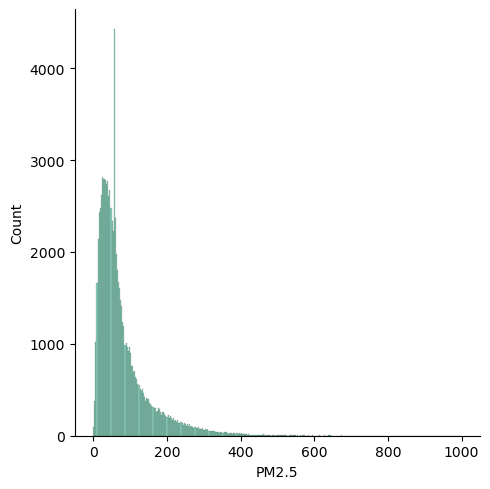

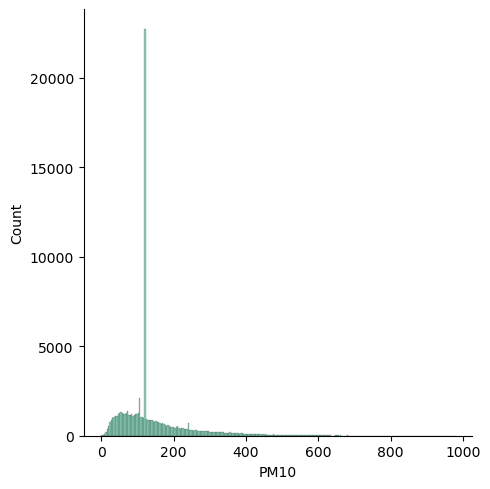

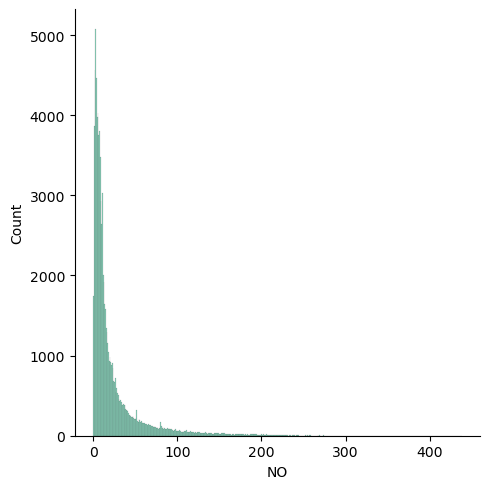

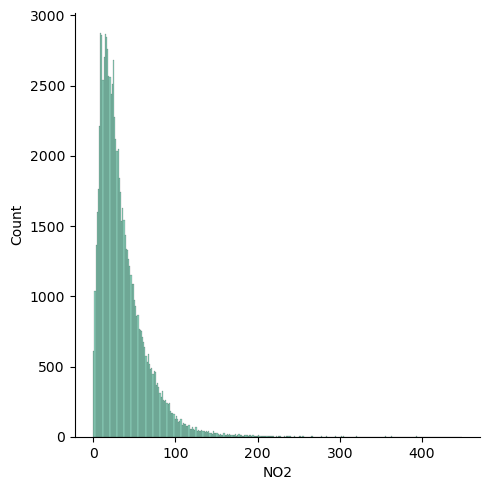

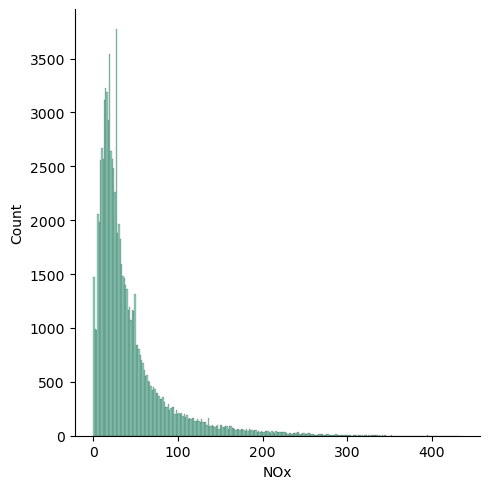

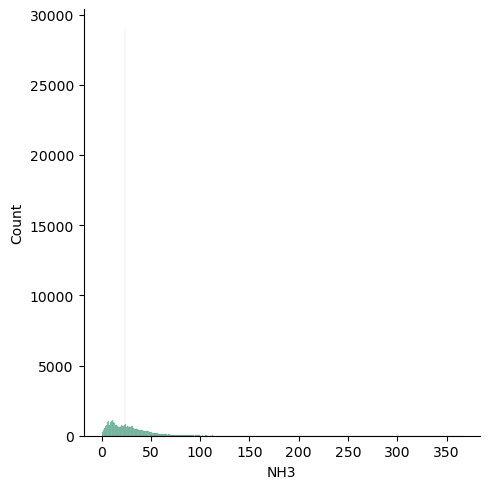

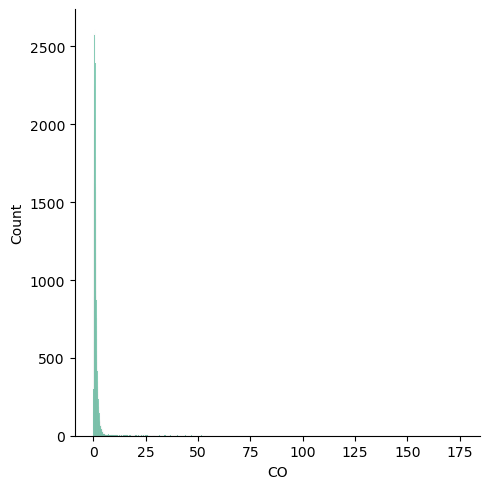

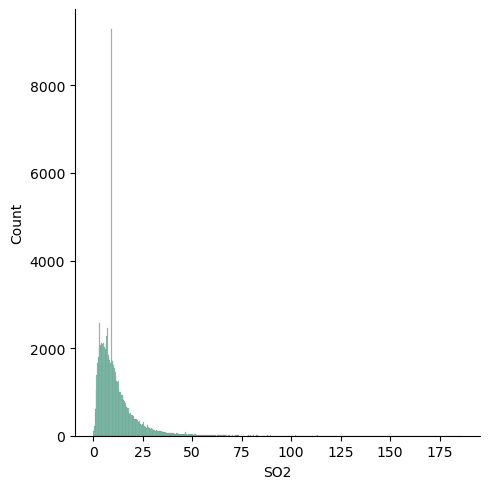

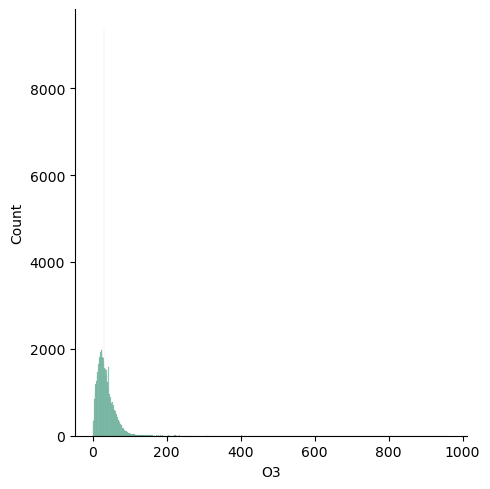

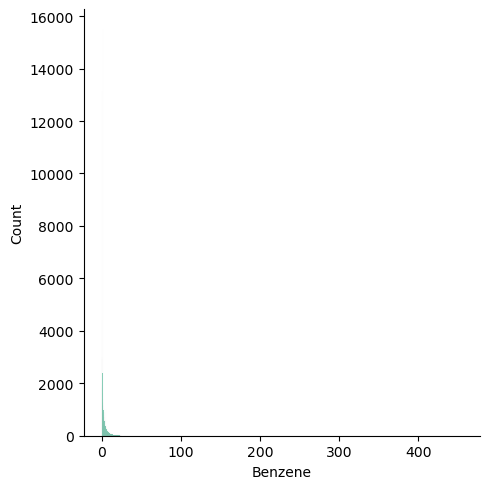

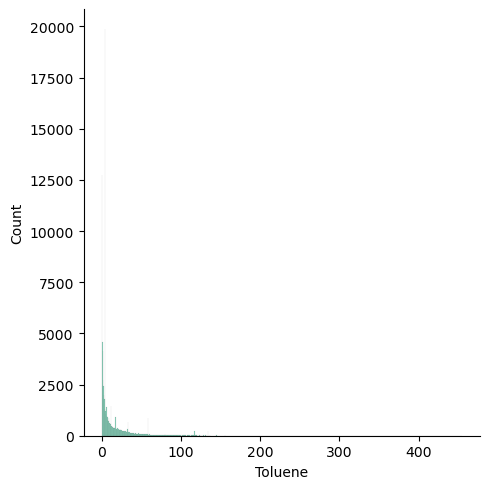

In [12]:
for pollutant in pollutants:
  sns.displot(data = df, x = pollutant)

In [15]:
# ── Summary statistics with skewness & kurtosis ───────────────────────────
stats_df = df[pollutants + ['AQI']].agg(['mean', 'median', 'std', 'skew'])
stats_df.loc['kurtosis'] = df[pollutants + ['AQI']].kurtosis()
stats_df.round(2).T.style.background_gradient(cmap='RdYlGn_r', subset=['skew', 'kurtosis'])

,mean,median,std,skew,kurtosis
PM2.5,79.500000,57.840000,74.600000,2.530000,9.900000
PM10,148.870000,120.700000,106.970000,2.090000,5.850000
NO,23.040000,10.370000,34.320000,3.240000,13.290000
NO2,35.030000,27.120000,28.890000,2.270000,10.180000
NOx,42.400000,27.310000,44.480000,2.570000,8.420000
NH3,26.950000,23.960000,19.700000,3.620000,27.340000
CO,1.600000,0.950000,4.190000,13.210000,257.280000
SO2,11.890000,9.070000,11.860000,4.520000,34.380000
O3,37.460000,29.990000,37.510000,7.250000,84.290000
Benzene,3.220000,1.150000,10.800000,20.890000,679.270000


In [16]:
# ── AQI Bucket distribution ───────────────────────────────────────────────
order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
palette = ['#2ca02c', '#98df8a', '#ffbb78', '#ff7f0e', '#d62728', '#8c0000']

counts = df['AQI_Bucket'].value_counts().reindex(order)
for i, val in list(enumerate(counts.values)):
  print(i)
  print(val)

0
5510
1
23636
2
29417
3
11493
4
11762
5
5207


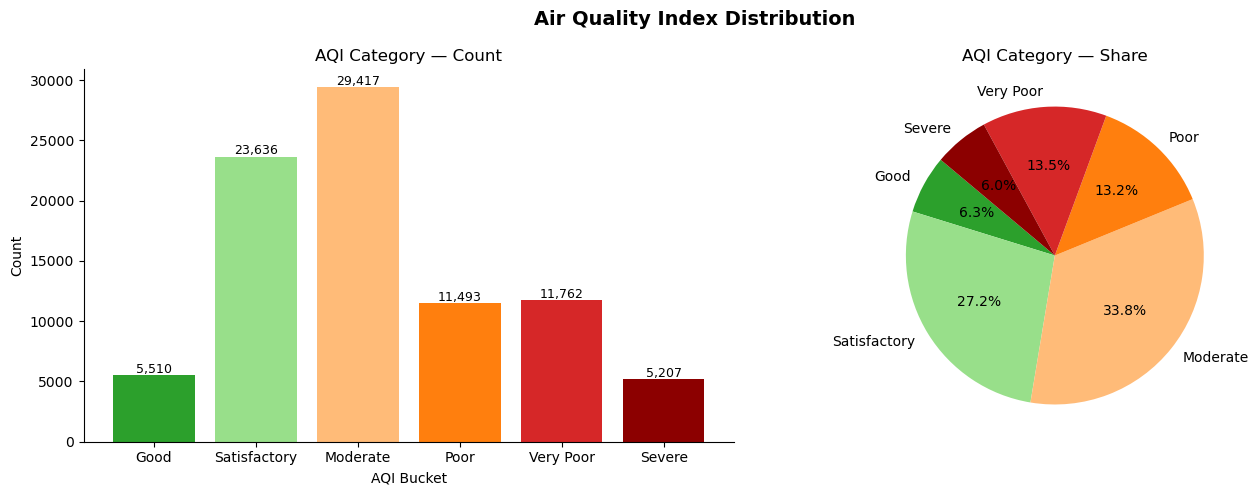

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar
axes[0].bar(counts.index, counts.values, color=palette)
axes[0].set_title('AQI Category — Count')
axes[0].set_xlabel('AQI Bucket')
axes[0].set_ylabel('Count')
for i, (val) in enumerate(counts.values):
    axes[0].text(i, val+200, f'{val:,}', ha='center', fontsize=9)

# Pie
axes[1].pie(counts.values, labels=counts.index, colors=palette,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('AQI Category — Share')

plt.suptitle('Air Quality Index Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

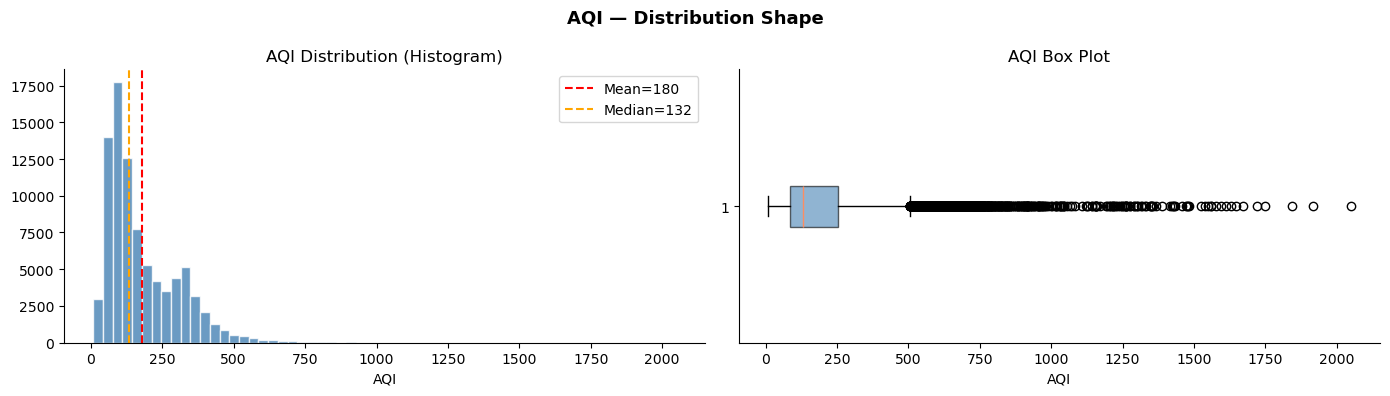

Skewness : 1.93  (>1 = right-skewed)
Kurtosis : 8.53


In [19]:
# ── AQI distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['AQI'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['AQI'].mean(), color='red', linestyle='--', label=f"Mean={df['AQI'].mean():.0f}")
axes[0].axvline(df['AQI'].median(), color='orange', linestyle='--', label=f"Median={df['AQI'].median():.0f}")
axes[0].set_title('AQI Distribution (Histogram)')
axes[0].set_xlabel('AQI')
axes[0].legend()

axes[1].boxplot(df['AQI'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('AQI Box Plot')
axes[1].set_xlabel('AQI')

plt.suptitle('AQI — Distribution Shape', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness : {df['AQI'].skew():.2f}  (>1 = right-skewed)")
print(f"Kurtosis : {df['AQI'].kurtosis():.2f}")

## Step 5 — Data Transformation

In [20]:
# ── Feature engineering ───────────────────────────────────────────────────
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
#df['Season']  = pd.cut(df['Month'],
                       #bins=[0, 2, 5, 8, 11, 12],
                       #labels=['Winter', 'Spring', 'Summer', 'Autumn', 'Winter'],
                       #ordered=False)
# Simplify: remap month-12 to Winter
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Log transform for highly skewed pollutants
skewed = [c for c in pollutants if df[c].skew() > 1.5]
for col in skewed:
    df[f'{col}_log'] = np.log1p(df[col])

# AQI ordinal encoding
aqi_order = {'Good': 1, 'Satisfactory': 2, 'Moderate': 3, 'Poor': 4, 'Very Poor': 5, 'Severe': 6}
df['AQI_Level'] = df['AQI_Bucket'].map(aqi_order)

print("New columns added:", ['Year','Month','Quarter','Season','AQI_Level'] + [f'{c}_log' for c in skewed])
print(f"\nHighly skewed pollutants (skew > 1.5): {skewed}")
df[['Date','Season','Year','Month','AQI','AQI_Level']].head(3)

New columns added: ['Year', 'Month', 'Quarter', 'Season', 'AQI_Level', 'PM2.5_log', 'PM10_log', 'NO_log', 'NO2_log', 'NOx_log', 'NH3_log', 'CO_log', 'SO2_log', 'O3_log', 'Benzene_log', 'Toluene_log']

Highly skewed pollutants (skew > 1.5): ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']


,Date,Season,Year,Month,AQI,AQI_Level
1,2017-11-25,Autumn,2017,11,184.0,3
2,2017-11-26,Autumn,2017,11,197.0,3
3,2017-11-27,Autumn,2017,11,198.0,3


## Step 6 — Visualize Data Relationships

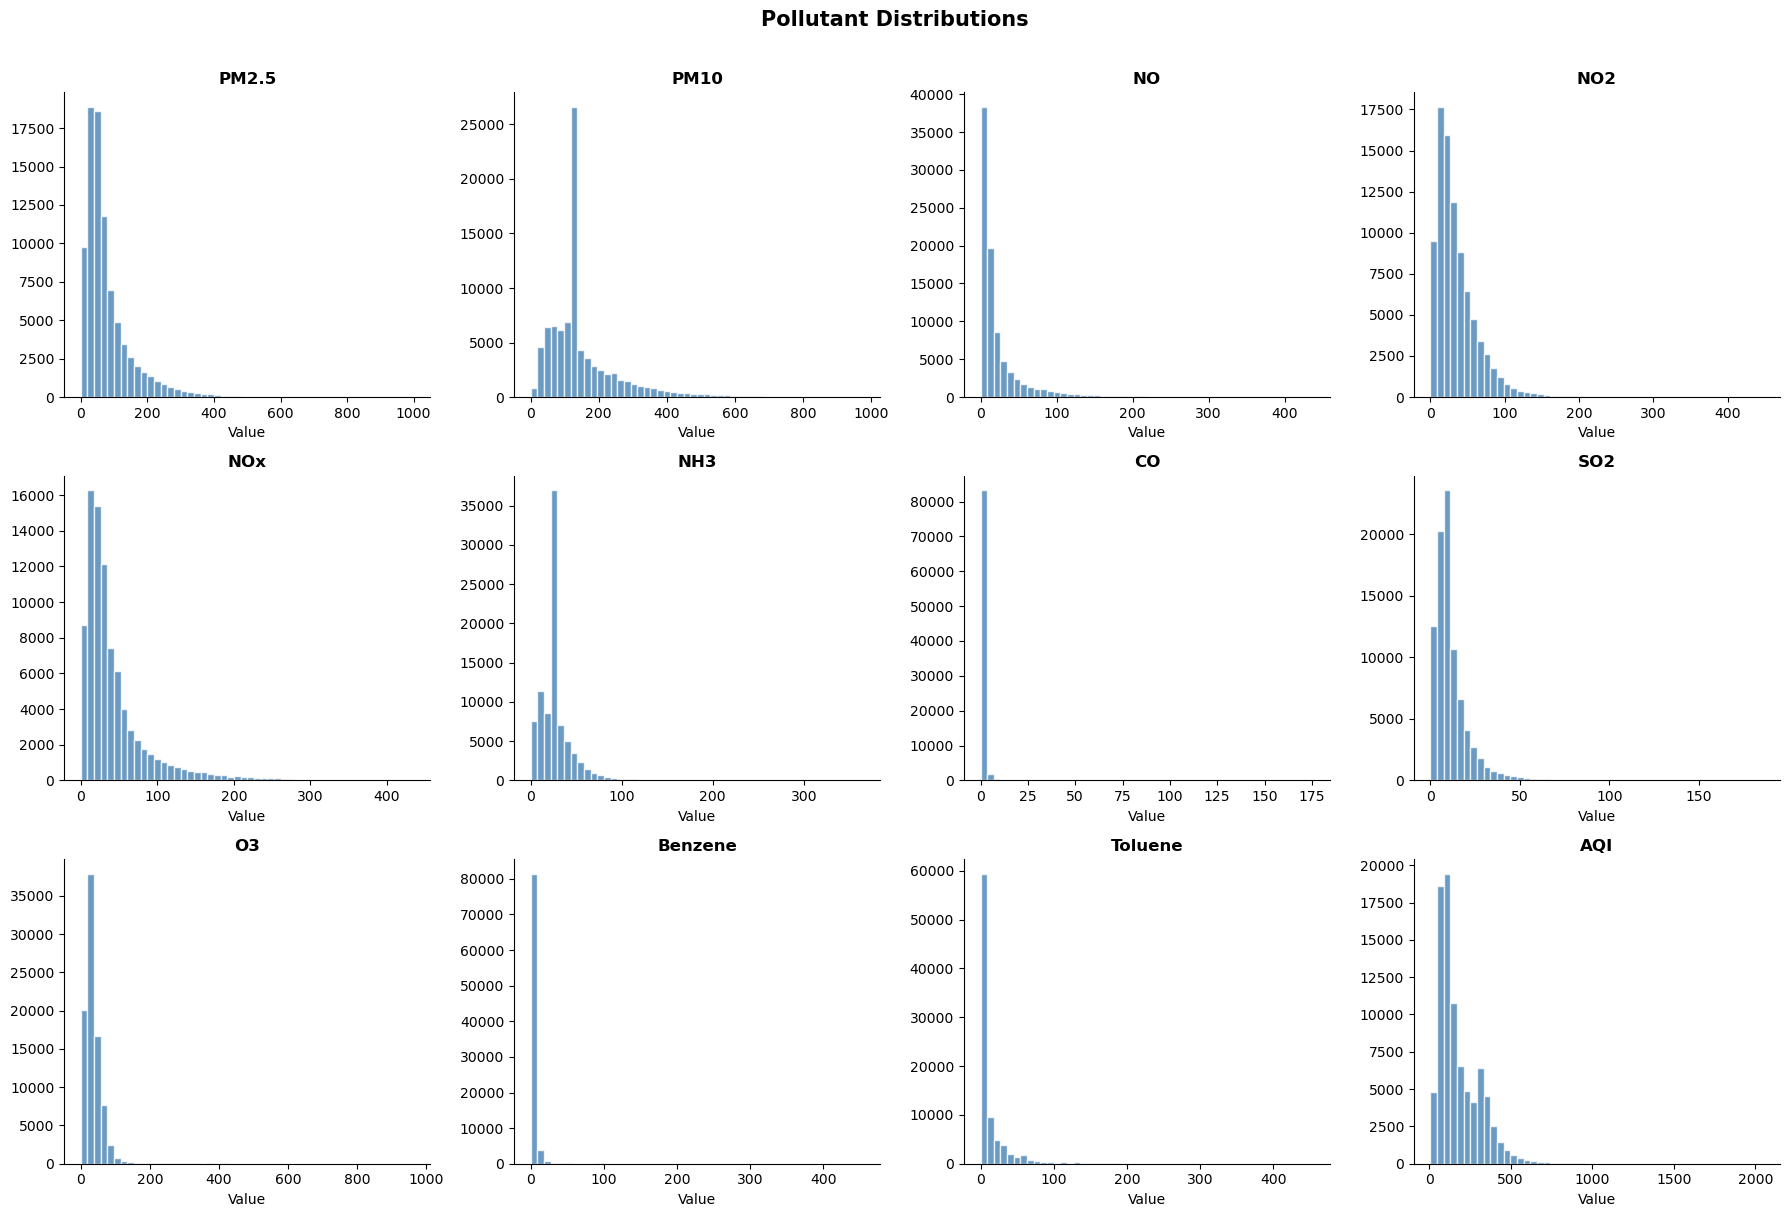

In [21]:
# ── 6a. Pollutant distributions — Histograms ─────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
cols = pollutants + ['AQI']

for i, col in enumerate(cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Pollutant Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

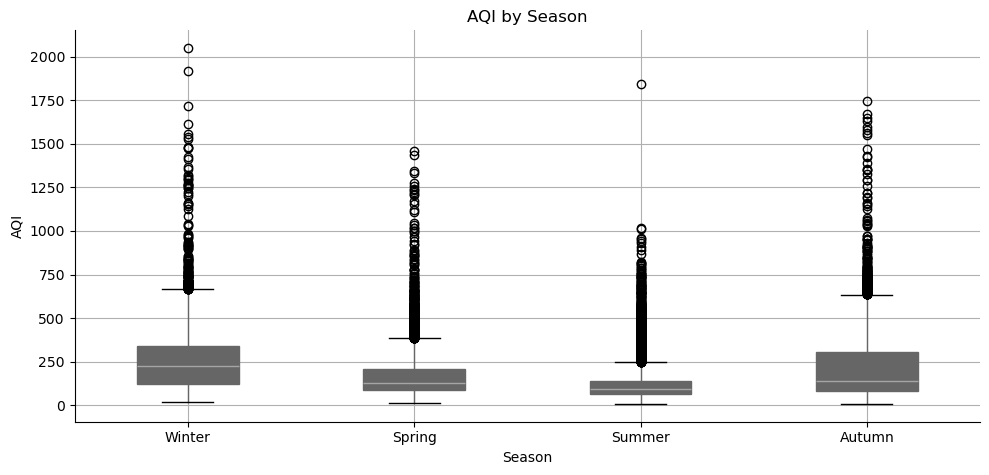

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ── 6b. AQI by Season — Box Plot ──────────────────────────────────────────
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_palette = {'Winter': '#4e91d2', 'Spring': '#82c45e',
                  'Summer': '#f4a34c', 'Autumn': '#c47a3a'}

# Convert 'Season' to a categorical type with the specified order
df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column='AQI', by='Season', ax=ax,
           patch_artist=True)
ax.set_title('AQI by Season')
ax.set_xlabel('Season')
ax.set_ylabel('AQI')
plt.suptitle('')
plt.tight_layout()
plt.show()

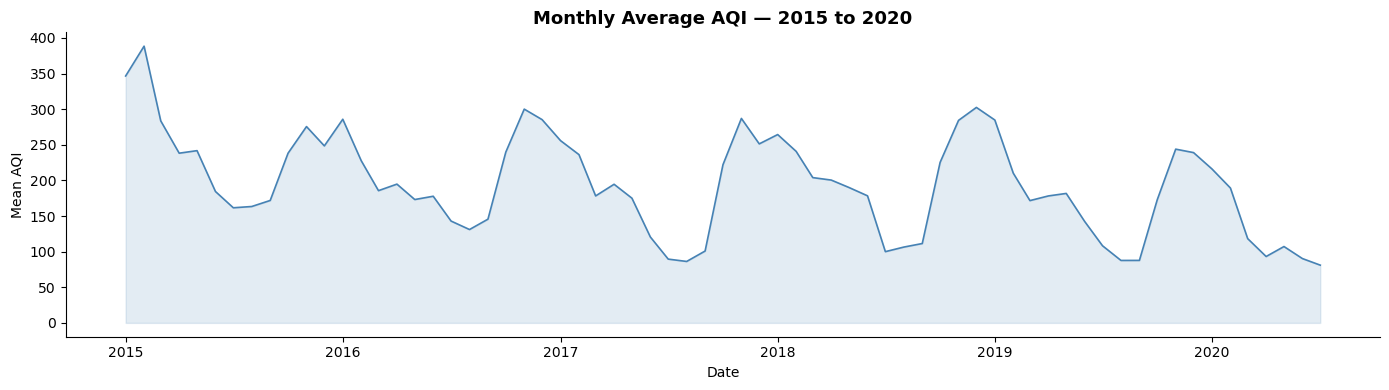

In [23]:
# ── 6c. Monthly AQI trend (2015–2020) ────────────────────────────────────
monthly = (df.groupby(['Year', 'Month'])['AQI']
             .mean()
             .reset_index())
monthly['Period'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['Period'], monthly['AQI'], color='steelblue', linewidth=1.2)
ax.fill_between(monthly['Period'], monthly['AQI'], alpha=0.15, color='steelblue')
ax.set_title('Monthly Average AQI — 2015 to 2020', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean AQI')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

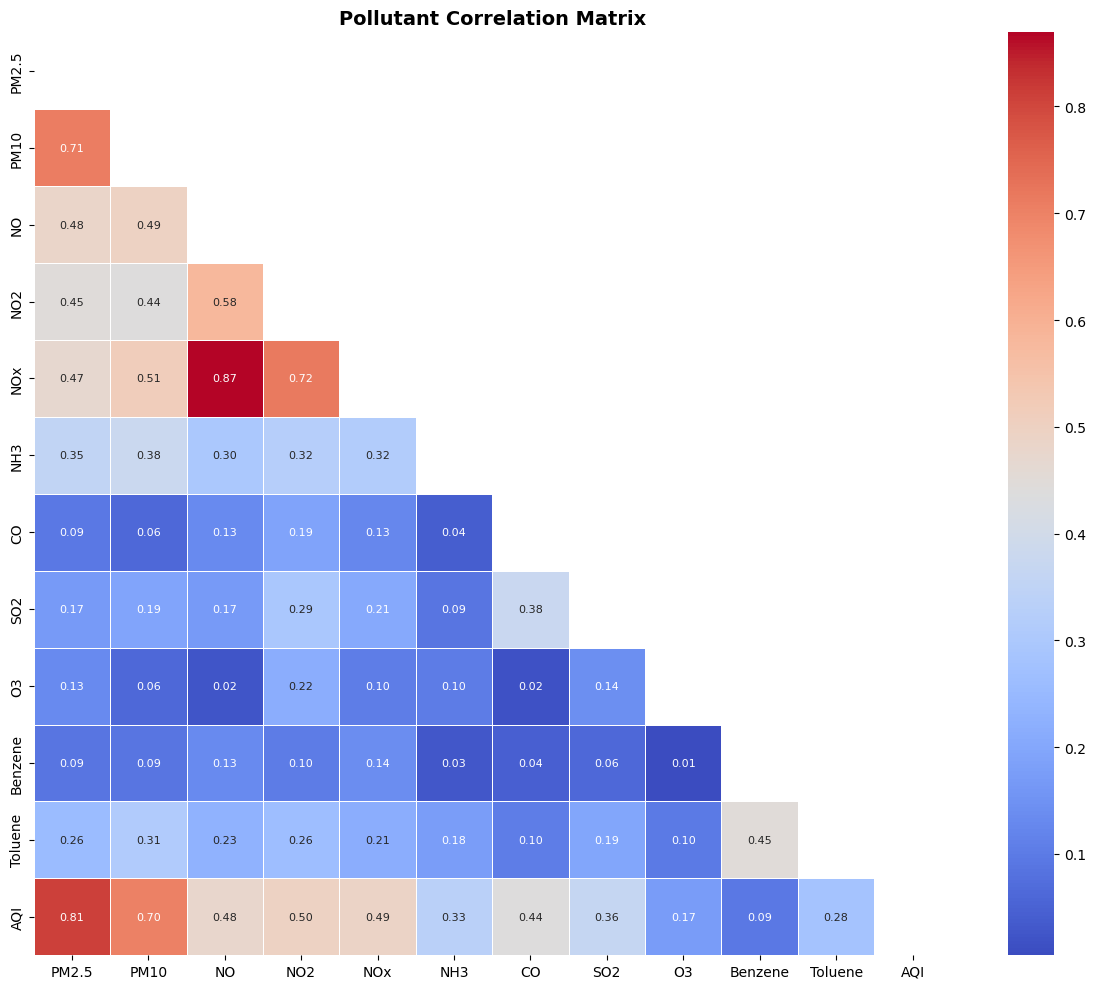

In [24]:
# ── 6d. Correlation heatmap ───────────────────────────────────────────────
corr_cols = pollutants + ['AQI']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Pollutant Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

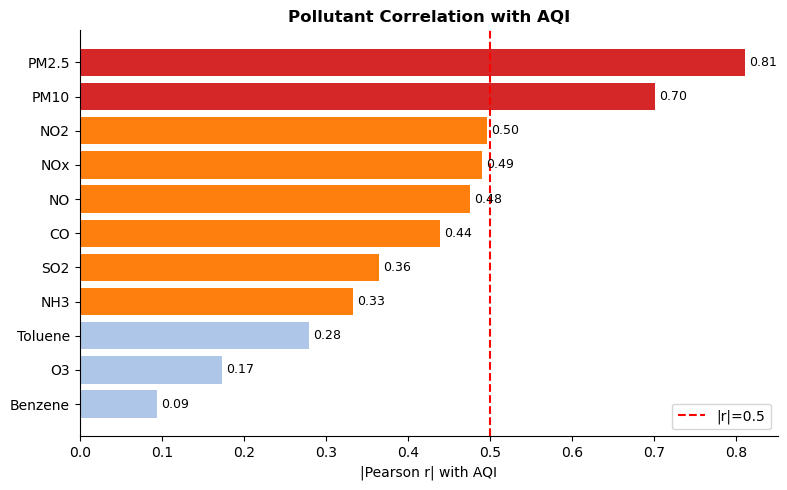

In [25]:
# ── 6e. Top 15 most correlated pollutants with AQI ───────────────────────
aqi_corr = corr['AQI'].drop('AQI').abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_corr = ['#d62728' if v > 0.5 else '#ff7f0e' if v > 0.3 else '#aec7e8'
               for v in aqi_corr]
ax.barh(aqi_corr.index, aqi_corr.values, color=colors_corr)
ax.axvline(0.5, color='red', linestyle='--', label='|r|=0.5')
ax.set_xlabel('|Pearson r| with AQI')
ax.set_title('Pollutant Correlation with AQI', fontweight='bold')
ax.legend()
for i, v in enumerate(aqi_corr.values):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

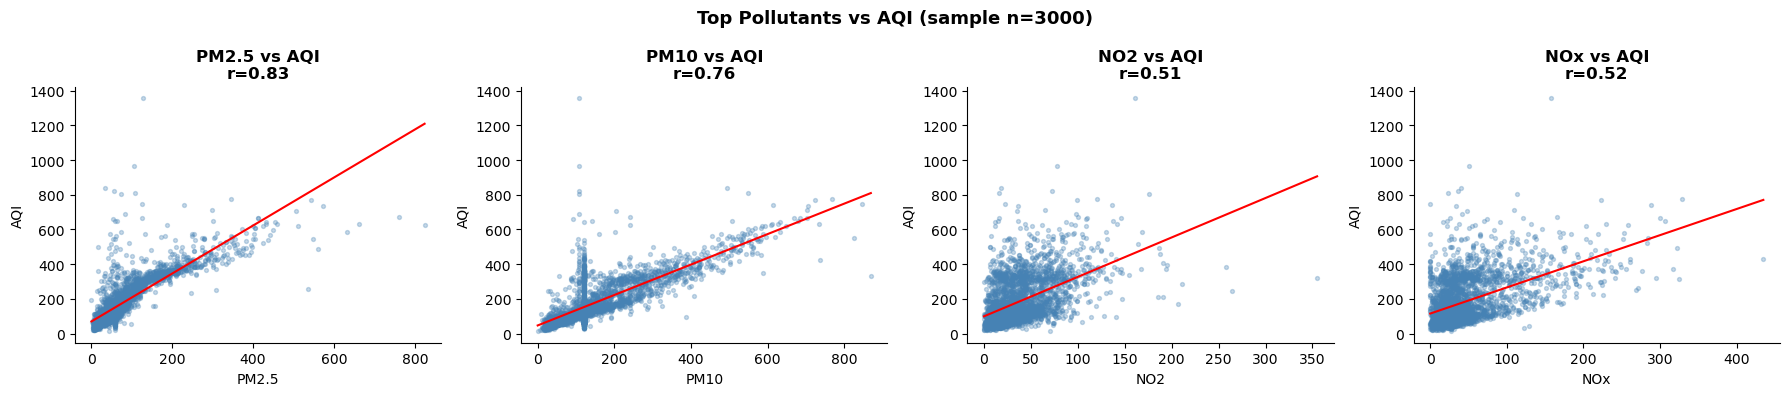

In [26]:
# ── 6f. Scatter plots — Top 4 correlated pollutants vs AQI ───────────────
top4 = corr['AQI'].drop('AQI').abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, top4):
    sample = df[[col, 'AQI']].dropna().sample(3000, random_state=42)
    ax.scatter(sample[col], sample['AQI'], alpha=0.3, s=8, color='steelblue')
    m, b, r, p, _ = stats.linregress(sample[col], sample['AQI'])
    x_line = np.linspace(sample[col].min(), sample[col].max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=1.5)
    ax.set_title(f'{col} vs AQI\nr={r:.2f}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('AQI')

plt.suptitle('Top Pollutants vs AQI (sample n=3000)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

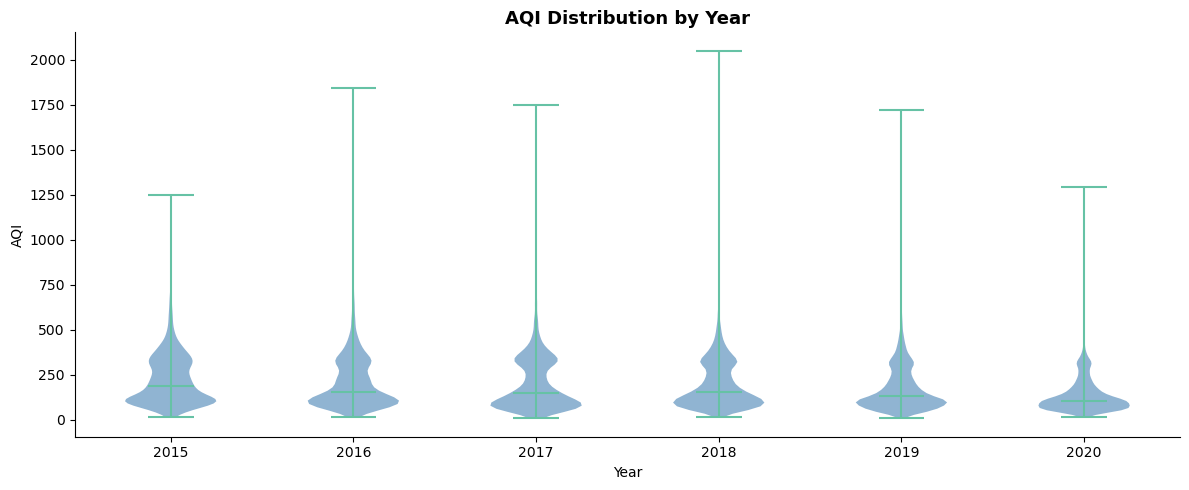

In [27]:
# ── 6g. Violin plot — AQI by year ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
years = sorted(df['Year'].unique())
data_by_year = [df.loc[df['Year'] == y, 'AQI'].dropna().values for y in years]

parts = ax.violinplot(data_by_year, positions=range(len(years)), showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.6)

ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_xlabel('Year')
ax.set_ylabel('AQI')
ax.set_title('AQI Distribution by Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

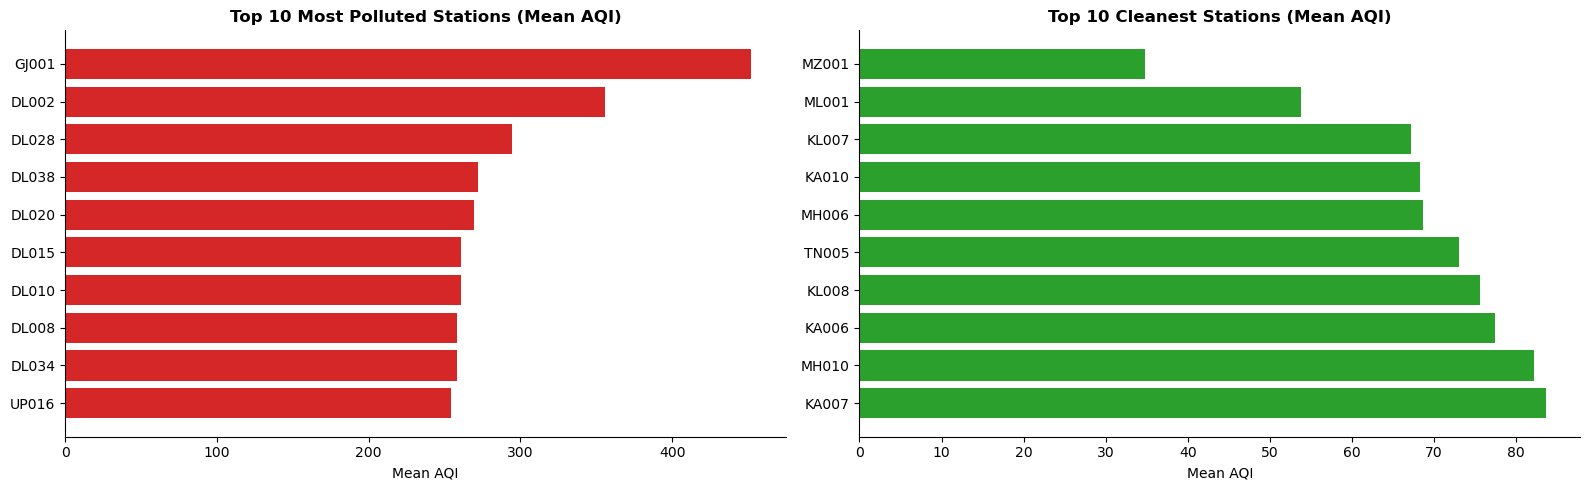

In [28]:
# ── 6h. Top 10 worst & best stations ─────────────────────────────────────
station_aqi = df.groupby('StationId')['AQI'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10_worst = station_aqi.head(10)
axes[0].barh(top10_worst.index[::-1], top10_worst.values[::-1], color='#d62728')
axes[0].set_title('Top 10 Most Polluted Stations (Mean AQI)', fontweight='bold')
axes[0].set_xlabel('Mean AQI')

top10_best = station_aqi.tail(10)
axes[1].barh(top10_best.index, top10_best.values, color='#2ca02c')
axes[1].set_title('Top 10 Cleanest Stations (Mean AQI)', fontweight='bold')
axes[1].set_xlabel('Mean AQI')

plt.tight_layout()
plt.show()

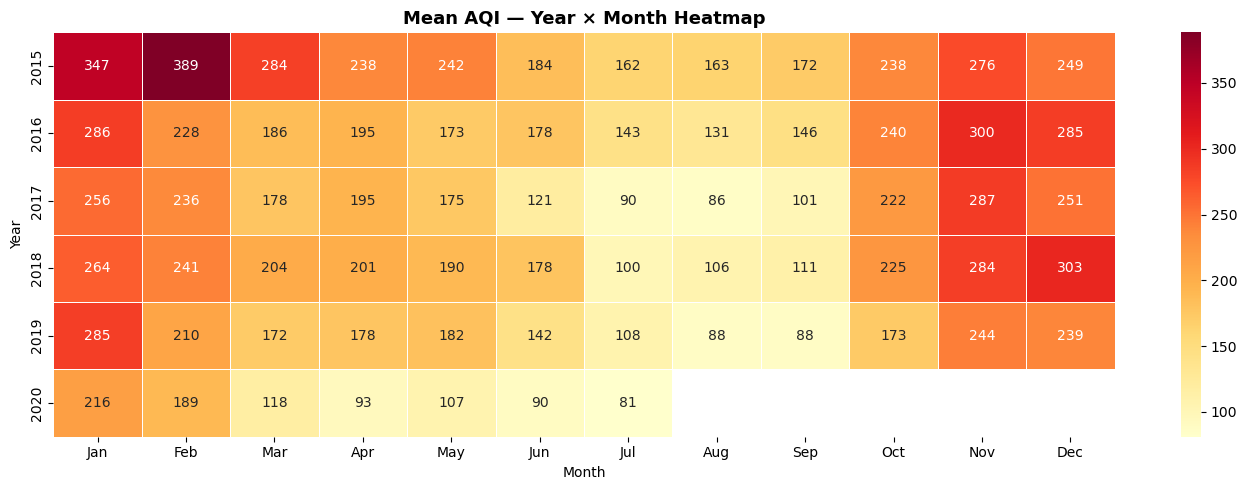

In [29]:
# ── 6i. Monthly AQI heatmap (year × month) ────────────────────────────────
pivot = df.pivot_table(values='AQI', index='Year', columns='Month', aggfunc='mean')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=month_labels, ax=ax, linewidths=0.5)
ax.set_title('Mean AQI — Year × Month Heatmap', fontsize=13, fontweight='bold')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

## Step 7 — Handle Outliers

         Outlier Count  Outlier %
Toluene          11269       12.9
NO                9699       11.1
PM10              8200        9.4
NH3               7771        8.9
Benzene           7779        8.9
NOx               7526        8.6
PM2.5             6776        7.8
CO                6050        7.0
SO2               5948        6.8
O3                3859        4.4
NO2               3533        4.1
AQI               1795        2.1


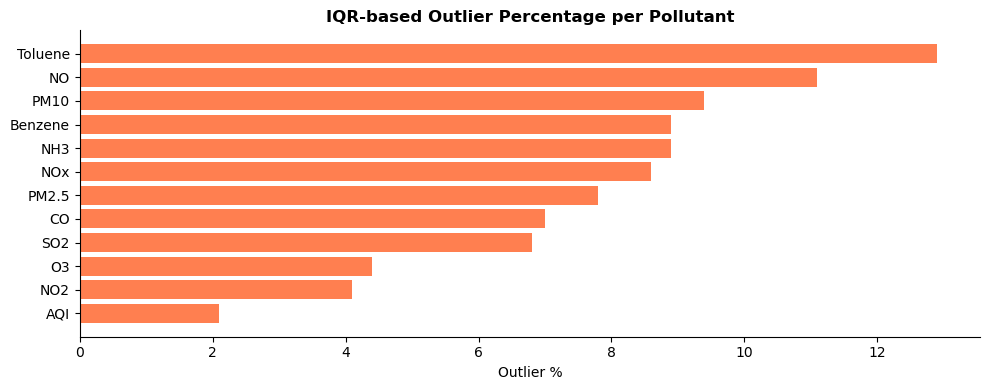

In [30]:
# ── IQR-based outlier detection ───────────────────────────────────────────
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum()

outlier_counts = {col: count_outliers_iqr(df[col].dropna()) for col in pollutants + ['AQI']}
outlier_pct = {k: round(v / len(df) * 100, 1) for k, v in outlier_counts.items()}

out_df = pd.DataFrame({'Outlier Count': outlier_counts, 'Outlier %': outlier_pct})
print(out_df.sort_values('Outlier %', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
out_sorted = out_df.sort_values('Outlier %', ascending=True)
ax.barh(out_sorted.index, out_sorted['Outlier %'], color='coral')
ax.set_xlabel('Outlier %')
ax.set_title('IQR-based Outlier Percentage per Pollutant', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# ── Z-score for AQI ───────────────────────────────────────────────────────
df['AQI_zscore'] = np.abs(stats.zscore(df['AQI'].fillna(df['AQI'].median())))
extreme = df[df['AQI_zscore'] > 3]
print(f"Extreme AQI outliers (|z|>3): {len(extreme):,} rows ({len(extreme)/len(df)*100:.1f}%)")
print(f"Max AQI: {df['AQI'].max():.1f}  |  99th pctile: {df['AQI'].quantile(0.99):.1f}")

# Winsorize AQI at 99th percentile for modeling use
cap = df['AQI'].quantile(0.99)
df['AQI_capped'] = df['AQI'].clip(upper=cap)
print(f"\nAQI capped at 99th pctile ({cap:.0f}) → use 'AQI_capped' for modeling")

Extreme AQI outliers (|z|>3): 996 rows (1.1%)
Max AQI: 2049.0  |  99th pctile: 588.8

AQI capped at 99th pctile (589) → use 'AQI_capped' for modeling


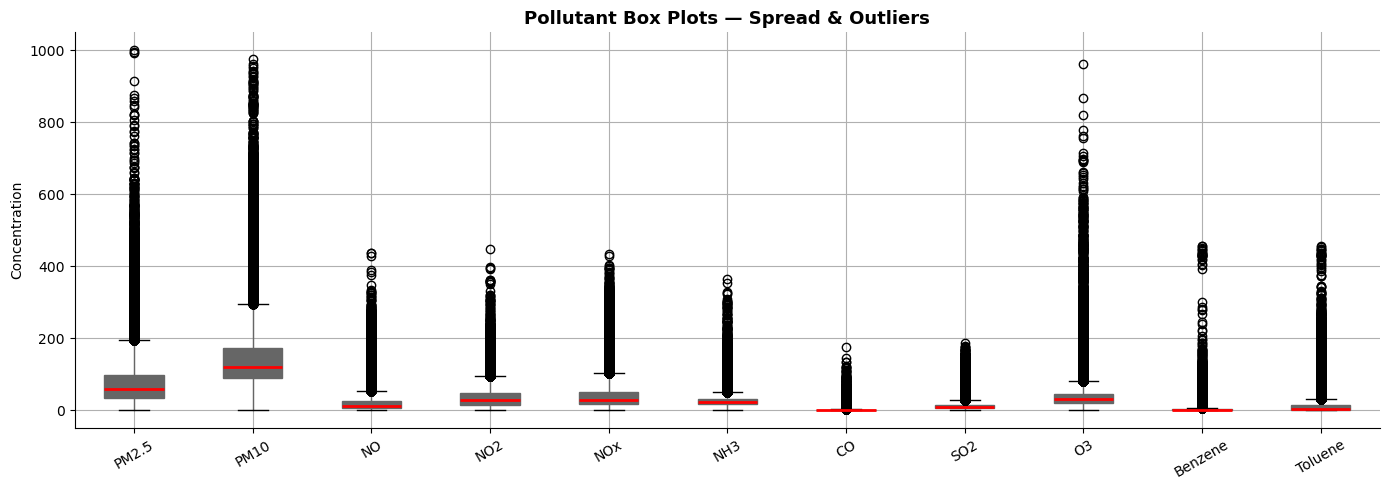

In [32]:
# ── Box plots for all pollutants to visualise spread & outliers ───────────
fig, ax = plt.subplots(figsize=(14, 5))
df[pollutants].boxplot(ax=ax, vert=True, patch_artist=True,
                       medianprops=dict(color='red', linewidth=2))
ax.set_title('Pollutant Box Plots — Spread & Outliers', fontsize=13, fontweight='bold')
ax.set_ylabel('Concentration')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 8 — Findings & Insights

### 📊 Key Findings

| # | Finding |
|---|----------|
| 1 | **Only 6.4% of days are 'Good'** — the majority (34%) fall in Moderate category |
| 2 | **PM2.5 and PM10** are the strongest drivers of AQI (highest correlation) |
| 3 | **Winter months (Nov–Jan) have the worst AQI** — confirmed by year×month heatmap |
| 4 | **Xylene was dropped** — 78.8% missing; too sparse for reliable analysis |
| 5 | **NH3 has 44% missing** — imputed but interpret NH3-based conclusions cautiously |
| 6 | **NO, NOx, CO show the most extreme outliers** — likely industrial/traffic hotspots |
| 7 | **AQI is right-skewed** (mean > median), suggesting heavy pollution events pull the average up |
| 8 | **Station-level variance is high** — some stations avg AQI >350 (Severe), others <60 (Satisfactory) |

### ⚠️ Limitations
- Xylene data too sparse for inclusion
- NH3 imputation may mask real seasonal variation in ammonia emissions
- AQI max of 2049 suggests measurement errors; winsorization at 99th pctile recommended for modeling

### 🔭 Suggested Next Steps
1. **Merge with stations.csv** to add geographic context (state, city, lat/lon)
2. **Time-series forecasting** — ARIMA or LSTM for station-level AQI prediction
3. **Clustering stations** by pollutant profile to identify industrial vs. residential patterns
4. **Feature importance** — use Random Forest to rank pollutant contributions to AQI
5. **Cross-validate AQI formula** against the official CPCB sub-index calculation

In [33]:
# ── Save cleaned dataset for downstream modeling ──────────────────────────
df.to_csv('station_day_cleaned.csv', index=False)
print(f"Saved: station_day_cleaned.csv  ({df.shape[0]:,} rows × {df.shape[1]} columns)")

Saved: station_day_cleaned.csv  (87,025 rows × 33 columns)
